## Example: 2D simulation of Taylor Green Vortex using Lattice Boltzmann Method


The example solves the Naiver Stokes Equation using Lattice Boltzmann Method. Here we setup the problem using an analytical solution of N-S equation: Taylor Green Vortex. Its velocity field and pressure field can be written as


$$u= -u_{\max} \cos \frac{2\pi x}{L} \sin \frac{2\pi y}{L} e^{-\nu t} $$ 

$$ v=u_{\max}\sin \frac{2\pi x}{L} \cos \frac{2\pi y}{L} e^{-\nu t} $$

$$p= -\frac {1}{4}  \rho_0 u_{\max}^2 ( \cos \frac{2\pi x}{L} + \cos \frac{2\pi y}{L} ) e^{-2\nu t} $$

Here, the Boltzmann equation is written as

$$\frac{\partial f}{\partial t}+ \xi_\alpha \frac{\partial f}{\partial x_\alpha} +\frac{f_\alpha}{\rho}\frac{\partial f}{\partial \xi_\alpha}=\Omega(f),$$

where the probability density function $f(\mathbf{x},\mathbf{\xi}, t)$, which is defined as a function of location $\mathbf{x}$, microscopic particle velocity $\mathbf{\xi}$, and time $t$. $f_\alpha$ is external forcing, and $\Omega(f)$ is the collision term.

The problem is solved in 2D using D2Q9 discretization, and the collision term is solved using BGK operator.


## Running the code

The simulation can be ran as `./mained.gnu.ex inputs`. 

The following inputs parameters could be tweaked:

```
scale = 2              # scale of the problem
max_grid_size = 64                # max grid size used for domain decomposition
Nx = 32    # size of the domain in both directions are Nx*scale
NSTEP=200  # number of time steps is NSTEP*scale*scale
plot_int=50 # interval of saving data, if not save, then set as -1
```


## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [2]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset

/tmp/ipykernel_9350/3074286631.py:3: DeprecationWarning: The historic 'boxlib' frontend is 
deprecated as it has been renamed 'amrex'. Existing and future work should instead reference the 'amrex' frontend.
Deprecated since yt 4.4.0
  from yt.frontends.boxlib.data_structures import AMReXDataset


yt : [INFO     ] 2025-05-04 11:40:22,379 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 11:40:22,380 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 11:40:22,381 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 11:40:22,382 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 11:40:22,596 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:40:22,597 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:40:22,599 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:40:22,599 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:40:22,601 Making a fixed resolution buffer of (('boxlib', 'vor')) 800 by 800


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]


/home/haotian/.local/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/haotian/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])



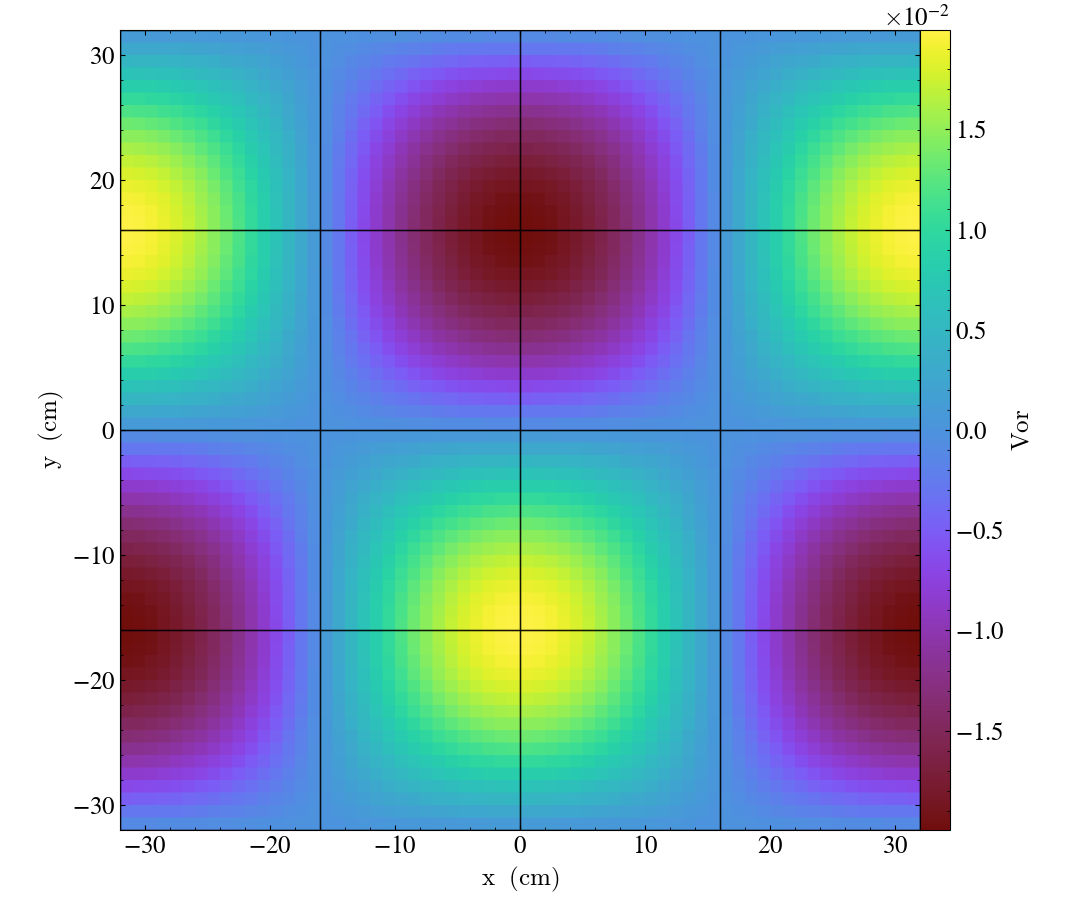

In [3]:
ds = AMReXDataset("plt00000")
print("Available fields:", ds.field_list)
field = ("boxlib", "vor" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

yt : [INFO     ] 2025-05-04 11:43:11,566 Parameters: current_time              = 150.0
yt : [INFO     ] 2025-05-04 11:43:11,566 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 11:43:11,567 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 11:43:11,568 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 11:43:11,681 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:43:11,681 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:43:11,683 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:43:11,684 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:43:11,685 Making a fixed resolution buffer of (('boxlib', 'vor')) 800 by 800


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]


/home/haotian/.local/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/haotian/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])



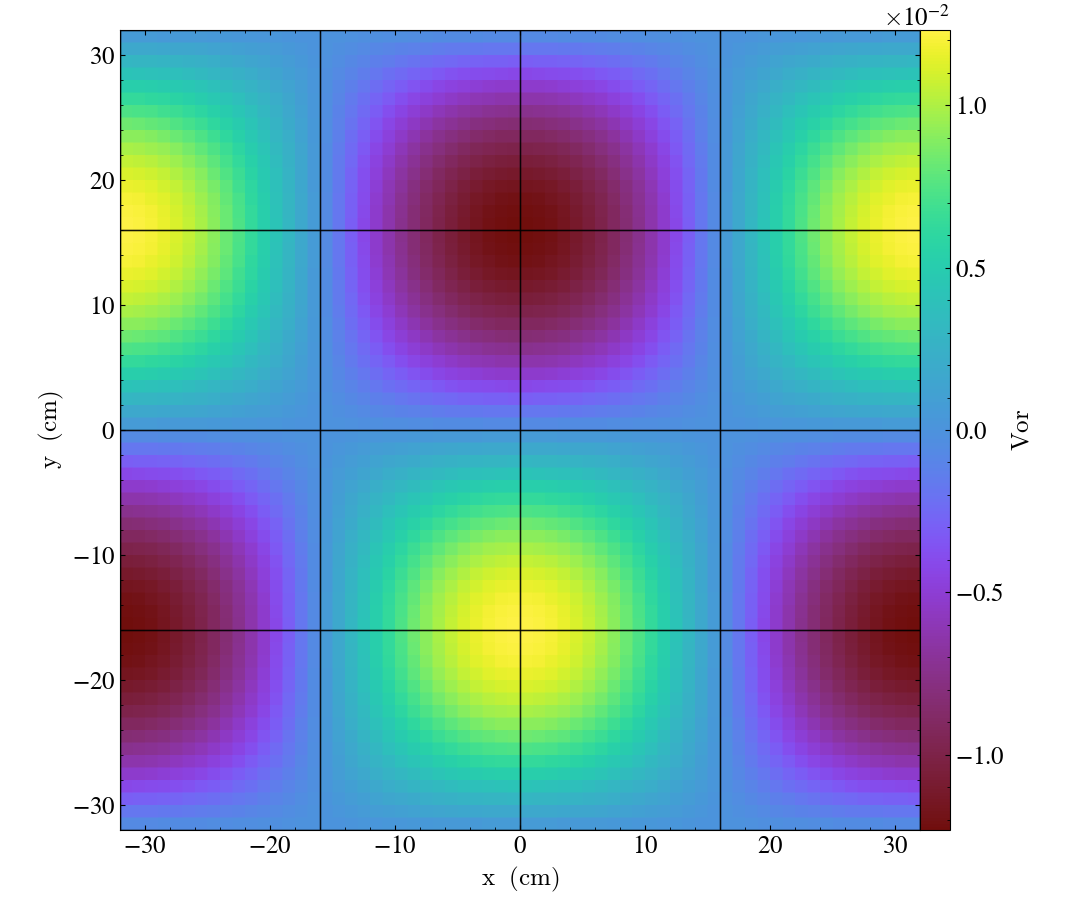

In [5]:
ds = AMReXDataset("plt00150")
print("Available fields:", ds.field_list)
field = ("boxlib", "vor" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()